In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
salary_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Salary_Data[1].csv')

In [ ]:
salary_data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
salary_data = salary_data.dropna()
print("Missing values in each column")
print(salary_data.isnull().sum())
print()

Missing values in each column
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64



In [ ]:
print(salary_data['Job Title'].nunique())
X = salary_data.drop(['Salary'], axis = 'columns')
y = salary_data['Salary']

X = pd.get_dummies(X, columns = ['Gender'])
X = pd.get_dummies(X, columns = ['Education Level'])
X = pd.get_dummies(X, columns = ['Job Title'])

191


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
LinearRegression()

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print('Coefficients:', model.coef_)
print(X_train.columns)
print('Intercept:', model.intercept_)
print('Mean Squared Error: %.2f' % mean_squared_error(y_test, y_pred))
print('Coefficient of Determination: %.2f' % r2_score(y_test, y_pred))


Coefficients: [ 1.11195480e+03  4.02688194e+03  6.16973100e+03  7.75507905e+03
 -1.39248101e+04  3.24895046e+04 -1.85314941e+04 -2.94320214e+04
  2.83826750e+04 -9.75911654e+03 -3.14954764e+03  7.42147677e-10
 -2.35428898e+04 -3.68187050e+04 -6.91808209e+04  5.02498009e+04
 -3.27086084e+04 -1.87406156e+04 -1.86017789e+04  5.09042850e+04
  9.94570035e+04  8.83463096e+04  3.89217031e+04 -4.04290767e+04
 -2.02121976e+04 -5.29587931e+04 -4.09024699e+04  1.43000000e+03
 -4.20144247e+04 -3.41782851e+04  4.18352712e+04 -3.40394484e+04
  6.83634545e+04  2.04086843e+04  5.82076609e-11  3.43708633e+04
  2.57846425e+04  2.29216147e+04  2.50827063e+03  8.08567440e+04
  2.73728958e+04  2.60613051e+03  2.55774561e+04  3.81594520e+03
  2.08312650e+04  4.15408564e+04  4.40777216e+03 -1.65744805e+03
  9.73218024e+03  3.02093311e+04 -5.08455869e+04 -1.09139364e-10
  3.91740772e+04  6.74628617e+04  3.84760165e+04  4.26269470e+04
  5.65586426e+04  1.87904780e+04 -5.72345848e+04 -4.05698187e+04
  6.5483618

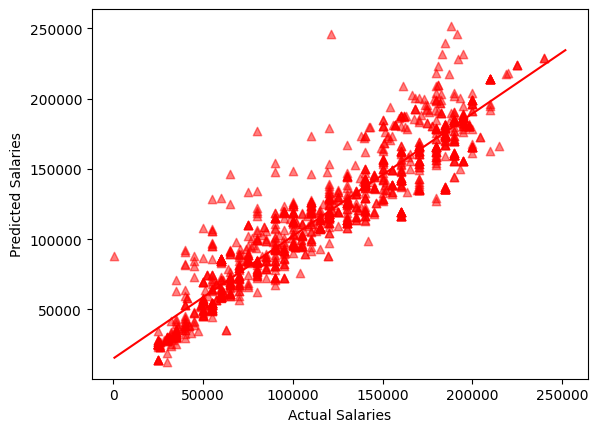

In [ ]:
plt.scatter(y_test, y_pred, alpha = 0.5, marker = "^", color = "red")
plt.xlabel("Actual Salaries")
plt.ylabel("Predicted Salaries")

m, b = np.polyfit(y_test, y_pred, 1)
x_line_reg = np.array([min(y_test), max(y_pred)])
y_line_reg = m * x_line_reg + b
plt.plot(x_line_reg, y_line_reg, color='red', linestyle='-', label='Connecting Line')
